<a href="https://colab.research.google.com/github/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/blob/main/Praktikum9/Bagging_%26_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 2. Load Dataset

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Decision Tree

In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

acc_tree_train = accuracy_score(y_train, tree.predict(X_train))
acc_tree_test = accuracy_score(y_test, tree.predict(X_test))

print("Decision Tree Train:", acc_tree_train)
print("Decision Tree Test :", acc_tree_test)

Decision Tree Train: 1.0
Decision Tree Test : 0.9473684210526315


# 4. Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Train:", acc_rf_train)
print("Random Forest Test :", acc_rf_test)

Random Forest Train: 1.0
Random Forest Test : 0.9649122807017544


Analisis :
1. Apakah Desicion Tree Overfit?
Jawab : Decision Tree mengalami overfitting karena akurasi training mencapai 100% sementara akurasi testing lebih rendah, yang menunjukkan model terlalu menyesuaikan diri dengan data training dan kurang generalisasi.
2. Apakah random forest lebih stabil?
Jawab : Random Forest lebih stabil, dapat terlihat dari lebih kecilnya gap antara akurasi training dan testing dibandingkan model Desicion Tree. Model menghasilkan akurasi testing yang lebih tinggi dan lebih konsisten dibanding Decision Tree, akibat penggunaan banyak pohon yang mengurangi variansi model.
3. Apakah grap train-test mengecil?
Jawab : Gap antara akurasi training dan testing pada Random Forest lebih kecil dibanding Decision Tree, yang menunjukkan bahwa Random Forest memiliki generalisasi yang lebih baik dan tidak terlalu overfitting.

# 5. Feature Importance

In [ ]:
importances = rf.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importance.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


# 6. Visualisasi Feature Importance

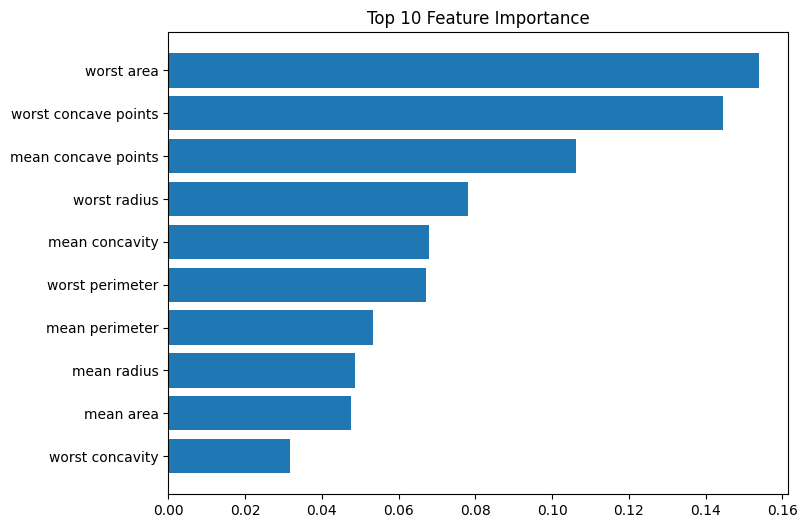

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"][:10],
         feat_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

Analisis :      
1. Fitur mana paling dominan?
Jawab : Fitur yang paling dominan adalah worst area dengan nilai importance tertinggi (0.153892), diikuti oleh worst concave points dan mean concave points. Hal ini menunjukkan bahwa ukuran dan bentuk tumor memiliki pengaruh besar dalam proses klasifikasi.
2. Apakah fitur tersebut intuitif secara medis?
Jawab : Ya,fitur-fitur yang dominan seperti ukuran dan bentuk tumor sesuai dengan pengetahuan medis, di mana tumor yang lebih besar dan memiliki bentuk tidak beraturan cenderung bersifat ganas.
3. Apakah ada fitur yang hampir tidak berpengaruh?
Jawab : Ya, terdapat beberapa fitur memiliki nilai importance yang sangat kecil atau tidak termasuk dalam 10 besar, sehingga kontribusinya terhadap model dapat dianggap tidak signifikan

Kesimpulan :
Berdasarkan hasil feature importance, fitur paling dominan adalah worst area, diikuti oleh fitur yang berkaitan dengan bentuk tumor seperti concave points. Fitur-fitur tersebut relevan secara medis karena ukuran dan ketidakteraturan bentuk tumor merupakan indikator penting dalam diagnosis kanker. Selain itu, terdapat beberapa fitur dengan nilai importance rendah yang menunjukkan bahwa tidak semua fitur memiliki kontribusi signifikan terhadap model.

# 7. Stability Test (Jumlah Estimator) : Uji n_estimators

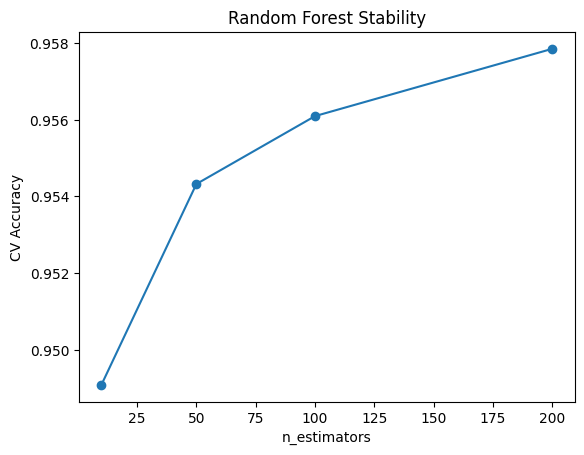

In [ ]:
estimators = [10, 50, 100, 200]
rf_scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores.append(score)

plt.plot(estimators, rf_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Stability")
plt.show()

Analisis :
1. Apakah performa stabil saat estimator bertambah?
Jawab : Ya, performa model semakin stabil (naik) saat jumlah estimator bertambah. Polanya Naik cepat di awal, lalu mulai melandai. Menunjukkan bahwa penambahan jumlah pohon dalam Random Forest dapat meningkatkan konsistensi prediksi.
2. Apakah peningkatan signifikan setelah 100?
Jawab : Peningkatan performa setelah 100 estimator tidak signifikan, karena kurva mulai melandai. Hal ini menunjukkan bahwa model telah mencapai kondisi optimal, sehingga penambahan estimator lebih lanjut hanya memberikan sedikit peningkatan.

Note Random Forest : Semakin banyak tree → prediksi semakin konsisten.

# 8. PCA + Random Forest

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
score_rf_pca = cross_val_score(rf_pca, X_pca, y, cv=5).mean()

score_rf = cross_val_score(rf, X, y, cv=5).mean()

print("RF tanpa PCA:", score_rf)
print("RF dengan PCA:", score_rf_pca)

RF tanpa PCA: 0.9560937742586555
RF dengan PCA: 0.9507529886663562


Analisis :
1. Apakah PCA meningkatkan performa?
Jawab : Tidak, terjadi penurunan performa. Dapat terlihat dari nilai akurasi yang lebih rendah dibandingkan tanpa PCA, sehingga PCA tidak memberikan manfaat pada model ini.
2. Mengapa tree-based model jarang membutuhkan PCA?
Jawab : Random Forest tidak memerlukan PCA karena mampu melakukan seleksi fitur secara otomatis melalui proses splitting. Selain itu, PCA dapat mengubah fitur menjadi kombinasi baru yang justru dapat menghilangkan informasi penting bagi model berbasis tree.
3. Apakah PCA menghilangkan interpretabilitas?
Jawab : PCA mengurangi interpretabilitas model karena mengubah fitur asli menjadi kombinasi linear (principal components) yang sulit diinterpretasikan secara langsung, sehingga tidak lagi merepresentasikan makna fitur secara nyata.



# Tugas Individu :      
1. Uji max_depth berbeda pada Random Forest.
2. Tambah Parameter : max_features dan min_samples_leaf
3. Bandingkan dengan Logistic Regression


max_depth=None -> Accuracy=0.9561
max_depth=1 -> Accuracy=0.9245
max_depth=5 -> Accuracy=0.9596
max_depth=10 -> Accuracy=0.9561
max_depth=15 -> Accuracy=0.9561
max_depth=20 -> Accuracy=0.9561


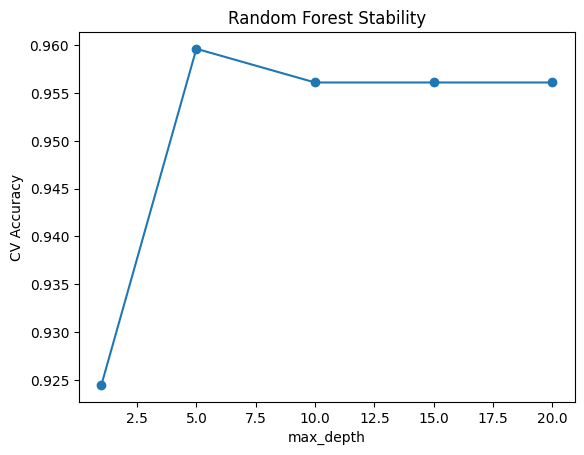

In [ ]:
# Uji paramater max_depth
max_depths = [None, 1, 5, 10, 15, 20]
rf_scores_depth = []

for depth in max_depths:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores_depth.append(score)

    print(f"max_depth={depth} -> Accuracy={score:.4f}")

# Visualisasi
plt.plot(max_depths, rf_scores_depth, marker='o')
plt.xlabel("max_depth")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Stability")
plt.show()

max_features=1 -> Accuracy=0.9578
max_features=5 -> Accuracy=0.9561
max_features=10 -> Accuracy=0.9596
max_features=15 -> Accuracy=0.9631
max_features=20 -> Accuracy=0.9596


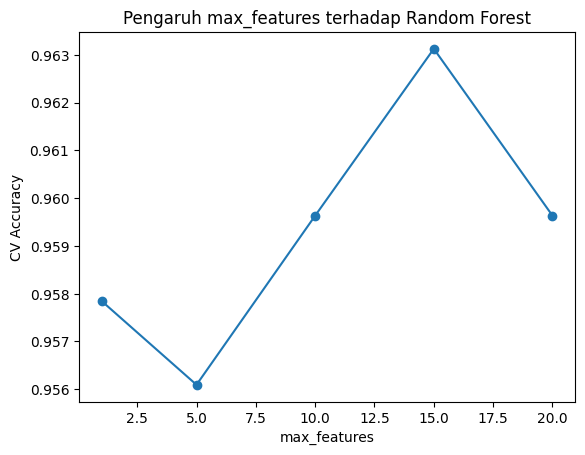

In [ ]:
# Uji Parameter max_features
max_features = [1, 5, 10, 15, 20]
rf_scores_feat = []

# Loop
for feat in max_features:
    model = RandomForestClassifier(
        n_estimators=100,
        max_features=feat,
        random_state=42
    )

    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores_feat.append(score)

# Print hasil
for f, s in zip(max_features, rf_scores_feat):
    print(f"max_features={f} -> Accuracy={s:.4f}")

# Visualisasi
plt.plot(max_features, rf_scores_feat, marker='o')
plt.xlabel("max_features")
plt.ylabel("CV Accuracy")
plt.title("Pengaruh max_features terhadap Random Forest")
plt.show()


min_samples_leaf=1 -> Accuracy=0.9561
min_samples_leaf=5 -> Accuracy=0.9561
min_samples_leaf=10 -> Accuracy=0.9508
min_samples_leaf=15 -> Accuracy=0.9456
min_samples_leaf=20 -> Accuracy=0.9420


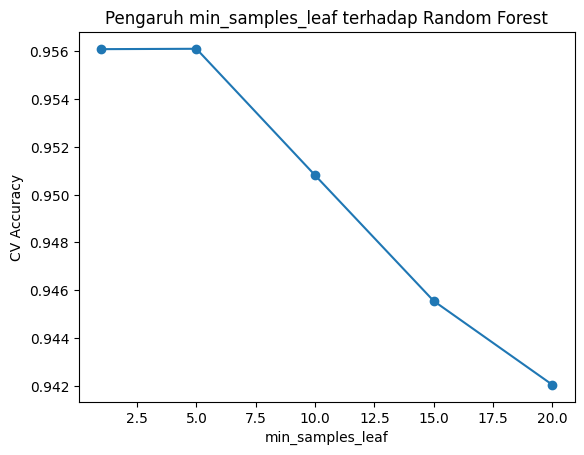

In [ ]:
# Uji Parameter min_samples_leaf
min_samples_leaf = [1, 5, 10, 15, 20]
rf_scores_leaf = []

for leaf in min_samples_leaf:
    model = RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=leaf,
        random_state=42
    )

    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores_leaf.append(score)

# Print hasil
for l, s in zip(min_samples_leaf, rf_scores_leaf):
    print(f"min_samples_leaf={l} -> Accuracy={s:.4f}")

# Visualisasi
plt.plot(min_samples_leaf, rf_scores_leaf, marker='o')
plt.xlabel("min_samples_leaf")
plt.ylabel("CV Accuracy")
plt.title("Pengaruh min_samples_leaf terhadap Random Forest")
plt.show()

Analisis : Nilai min_samples_leaf yang lebih besar membuat model lebih sederhana dan mampu mengurangi overfitting, namun jika terlalu besar dapat menurunkan akurasi karena model menjadi kurang fleksibel.

In [ ]:
# Mencari model RF dengan kombinasi paramter terbaik untuk menghasilkna performa optimal
max_depths = [None, 5, 10, 15]
max_features = [5, 10, "sqrt"]
min_samples_leaf = [1, 5, 10]

results = []

for depth in max_depths:
    for feat in max_features:
        for leaf in min_samples_leaf:

            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                max_features=feat,
                min_samples_leaf=leaf,
                random_state=42
            )

            score = cross_val_score(model, X, y, cv=5).mean()

            results.append({
                'max_depth': depth,
                'max_features': feat,
                'min_samples_leaf': leaf,
                'accuracy': score
            })

# Simpan ke Dataframe
df = pd.DataFrame(results)

# Sorting hasil terbaik
df_sorted = df.sort_values(by='accuracy', ascending=False)
print("Top 10 Kombinasi Terbaik:")
print(df_sorted.head(10))

# Parameter terbaik
best_rf = df_sorted.iloc[0]

print("\nBest Parameters:")
print(best_rf)

Top 10 Kombinasi Terbaik:
    max_depth max_features  min_samples_leaf  accuracy
12        5.0           10                 1  0.961341
3         NaN           10                 1  0.959634
21       10.0           10                 1  0.959634
30       15.0           10                 1  0.959634
15        5.0         sqrt                 1  0.959618
9         5.0            5                 1  0.959618
13        5.0           10                 5  0.959603
16        5.0         sqrt                 5  0.957864
10        5.0            5                 5  0.957864
22       10.0           10                 5  0.957848

Best Parameters:
max_depth                5.0
max_features              10
min_samples_leaf           1
accuracy            0.961341
Name: 12, dtype: object


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

score_lr = cross_val_score(pipeline, X, y, cv=5).mean()

print("Logistic Regression Score:", score_lr)

Logistic Regression Score: 0.9806862288464524


In [ ]:
# Perbandingan model RF (kombinasi parameter terbaik) vs Logistic Regression
print("\nPERBANDINGAN")
print("Random Forest Best Score :", best_rf['accuracy'])
print("Logistic Regression     :", score_lr)


=== PERBANDINGAN ===
Random Forest Best Score : 0.9613414066138798
Logistic Regression     : 0.9806862288464524


In [ ]:
# Tabel Eksperimen : akurasi model RF dari berbagai kombinasi parameter
print(df_sorted.head(10).to_string(index=False))

print(f"\nLogistic Regression : {score_lr:.4f}")
print(f"Random Forest terbaik: {best_rf['accuracy']:.4f}")

 max_depth max_features  min_samples_leaf  accuracy
       5.0           10                 1  0.961341
       NaN           10                 1  0.959634
      10.0           10                 1  0.959634
      15.0           10                 1  0.959634
       5.0         sqrt                 1  0.959618
       5.0            5                 1  0.959618
       5.0           10                 5  0.959603
       5.0         sqrt                 5  0.957864
       5.0            5                 5  0.957864
      10.0           10                 5  0.957848

Logistic Regression : 0.9807
Random Forest terbaik: 0.9613


=== Statistik Feature Importance ===
Total fitur       : 30
Fitur dominan (>0.05) : 7
Fitur lemah (<0.01)   : 11

Top 5 Fitur:
             Feature  Importance
          worst area    0.153892
worst concave points    0.144663
 mean concave points    0.106210
        worst radius    0.077987
      mean concavity    0.068001


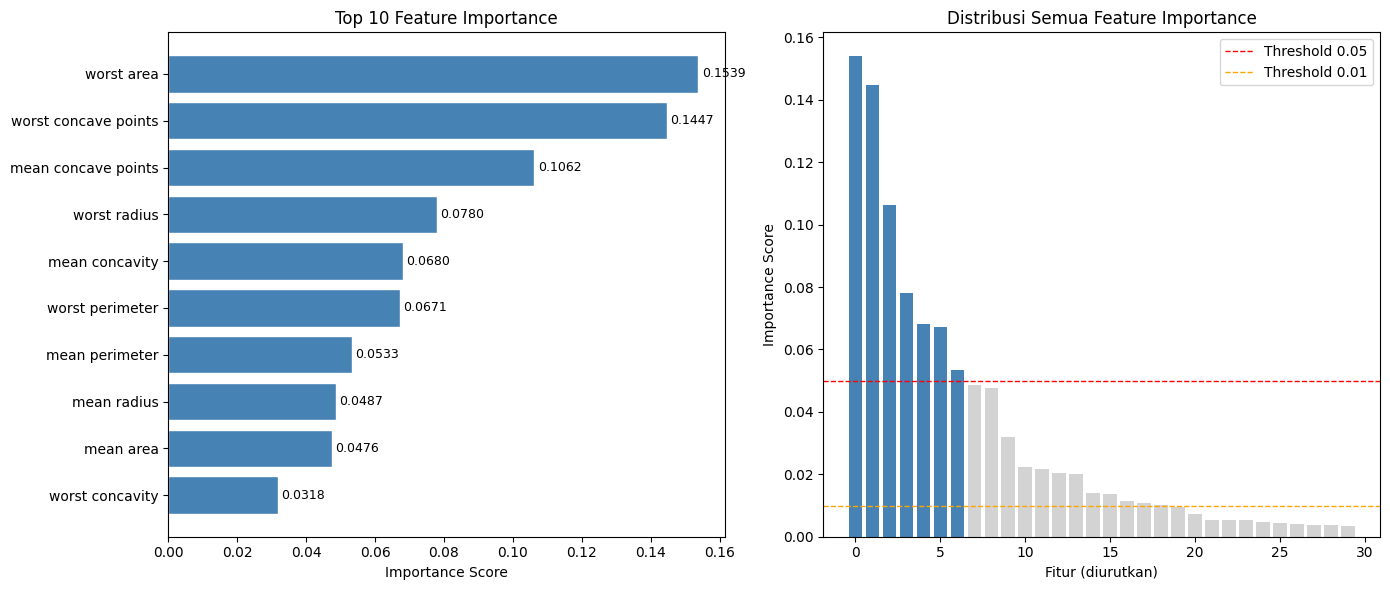


=== Kelompok Fitur Berdasarkan Importance ===

Dominan  (>= 0.05) — 7 fitur
             Feature  Importance
          worst area    0.153892
worst concave points    0.144663
 mean concave points    0.106210
        worst radius    0.077987
      mean concavity    0.068001
     worst perimeter    0.067115
      mean perimeter    0.053270

Sedang (0.01–0.05) — 12 fitur
          Feature  Importance
      mean radius    0.048703
        mean area    0.047555
  worst concavity    0.031802
       area error    0.022407
    worst texture    0.021749
worst compactness    0.020266
     radius error    0.020139
 mean compactness    0.013944
     mean texture    0.013591
  perimeter error    0.011303
 worst smoothness    0.010644
   worst symmetry    0.010120

Lemah    (< 0.01) — 11 fitur
                Feature  Importance
        concavity error    0.009386
        mean smoothness    0.007285
fractal dimension error    0.005321
      compactness error    0.005253
worst fractal dimension    0

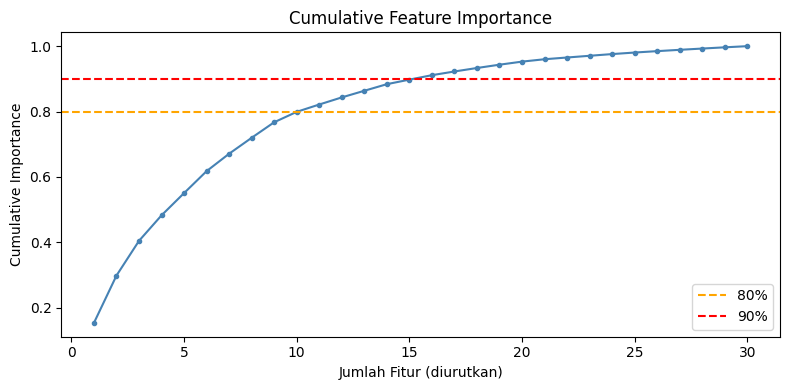

In [ ]:
# Analisis Feature Importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ambil semua feature importance
feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# 1. Statistik deskriptif
print("=== Statistik Feature Importance ===")
print(f"Total fitur       : {len(feat_importance)}")
print(f"Fitur dominan (>0.05) : {(feat_importance['Importance'] > 0.05).sum()}")
print(f"Fitur lemah (<0.01)   : {(feat_importance['Importance'] < 0.01).sum()}")
print(f"\nTop 5 Fitur:")
print(feat_importance.head(5).to_string(index=False))

# 2. Visualisasi full bar chart (semua fitur)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(
    feat_importance["Feature"][:10],
    feat_importance["Importance"][:10],
    color="steelblue", edgecolor="white"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Feature Importance")
axes[0].set_xlabel("Importance Score")
for i, val in enumerate(feat_importance["Importance"][:10]):
    axes[0].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=9)

axes[1].bar(
    range(len(feat_importance)),
    feat_importance["Importance"],
    color=["steelblue" if v >= 0.05 else "lightgray" for v in feat_importance["Importance"]]
)
axes[1].set_title("Distribusi Semua Feature Importance")
axes[1].set_xlabel("Fitur (diurutkan)")
axes[1].set_ylabel("Importance Score")
axes[1].axhline(y=0.05, color="red", linestyle="--", linewidth=1, label="Threshold 0.05")
axes[1].axhline(y=0.01, color="orange", linestyle="--", linewidth=1, label="Threshold 0.01")
axes[1].legend()

plt.tight_layout()
plt.savefig("feature_importance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Tabel kelompok fitur untuk laporan
print("\n=== Kelompok Fitur Berdasarkan Importance ===")
groups = {
    "Dominan  (>= 0.05)": feat_importance[feat_importance["Importance"] >= 0.05],
    "Sedang (0.01–0.05)": feat_importance[(feat_importance["Importance"] >= 0.01) & (feat_importance["Importance"] < 0.05)],
    "Lemah    (< 0.01)" : feat_importance[feat_importance["Importance"] < 0.01],
}
for label, group in groups.items():
    print(f"\n{label} — {len(group)} fitur")
    print(group[["Feature", "Importance"]].to_string(index=False))

#  4. Cumulative importance (berapa fitur cukup untuk 80% / 90%)
feat_importance["Cumulative"] = feat_importance["Importance"].cumsum()

thresh_80 = feat_importance[feat_importance["Cumulative"] <= 0.80].shape[0] + 1
thresh_90 = feat_importance[feat_importance["Cumulative"] <= 0.90].shape[0] + 1

print(f"\n=== Cumulative Importance ===")
print(f"Fitur dibutuhkan untuk mencapai 80% importance : {thresh_80} fitur")
print(f"Fitur dibutuhkan untuk mencapai 90% importance : {thresh_90} fitur")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(feat_importance) + 1), feat_importance["Cumulative"], marker=".", color="steelblue")
plt.axhline(y=0.80, color="orange", linestyle="--", label="80%")
plt.axhline(y=0.90, color="red", linestyle="--", label="90%")
plt.xlabel("Jumlah Fitur (diurutkan)")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance")
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Analisis :

1.  **Statistik Deskriptif**: Menampilkan jumlah fitur, fitur dominan (importance > 0.05), dan fitur lemah (importance < 0.01), serta 5 fitur teratas.
2.  **Visualisasi Bar Chart**: Menyajikan dua grafik:
    *   **Top 10 Feature Importance**: Menunjukkan 10 fitur terpenting dengan skor masing-masing.
    *   **Distribusi Semua Feature Importance**: Menampilkan semua fitur yang diurutkan berdasarkan importance, dengan garis threshold untuk 0.05 (merah) dan 0.01 (oranye) untuk membedakan fitur dominan, sedang, dan lemah.
3.  **Tabel Kelompok Fitur**: Mengelompokkan fitur ke dalam tiga kategori (Dominan, Sedang, Lemah) berdasarkan skor importance untuk memberikan gambaran yang lebih jelas.
4.  **Cumulative Importance**: Mengukur berapa banyak fitur yang dibutuhkan untuk mencapai 80% dan 90% dari total importance. Ini membantu dalam proses seleksi fitur untuk mengurangi dimensi tanpa kehilangan terlalu banyak informasi penting.


Kesimpulan Analisis Feature Importance :

1.  **Fitur Paling Dominan**: Fitur-fitur seperti `worst area`, `worst concave points`, dan `mean concave points` memiliki skor kepentingan (importance) tertinggi. Ini menunjukkan bahwa karakteristik yang berkaitan dengan ukuran dan bentuk tumor adalah prediktor yang sangat kuat dalam model Random Forest untuk kasus kanker payudara ini.

2.  **Relevansi Medis**: Dominansi fitur-fitur tersebut sangat intuitif secara medis. Ukuran dan ketidakteraturan bentuk massa (tumor) adalah indikator krusial yang sering digunakan dalam diagnosis klinis untuk membedakan antara massa jinak dan ganas.

3.  **Fitur Kurang Berpengaruh**: Terdapat sejumlah fitur dengan nilai kepentingan yang sangat rendah (di bawah 0.01), yang menunjukkan bahwa kontribusinya terhadap kemampuan prediksi model sangat minimal. Fitur-fitur ini berpotensi untuk dihilangkan tanpa mengurangi performa model secara signifikan, bahkan mungkin meningkatkan efisiensi komputasi.

4.  **Seleksi Fitur Potensial**: Untuk mencapai 80% dari total kepentingan kumulatif, model hanya membutuhkan sekitar 11 fitur teratas. Ini mengindikasikan adanya redundansi fitur dan peluang besar untuk melakukan reduksi dimensi, yang dapat menyederhanakan model tanpa mengorbankan terlalu banyak informasi penting.

Secara keseluruhan, analisis ini mengkonfirmasi bahwa Random Forest berhasil mengidentifikasi fitur-fitur diagnostik yang relevan secara klinis dan memberikan wawasan untuk potensi optimasi model melalui seleksi fitur.

## Note : Eksperimen tambahan  untuk menguji model dengan kombinasi 3 paramter terbaik sebelumnya dengan ditambahkan berbagai nilai n_estimators

Best Parameters:
max_depth=5, max_features=10, min_samples_leaf=1
n_estimators=50 -> Accuracy=0.9561
n_estimators=100 -> Accuracy=0.9613
n_estimators=200 -> Accuracy=0.9649
n_estimators=300 -> Accuracy=0.9614
n_estimators=500 -> Accuracy=0.9596


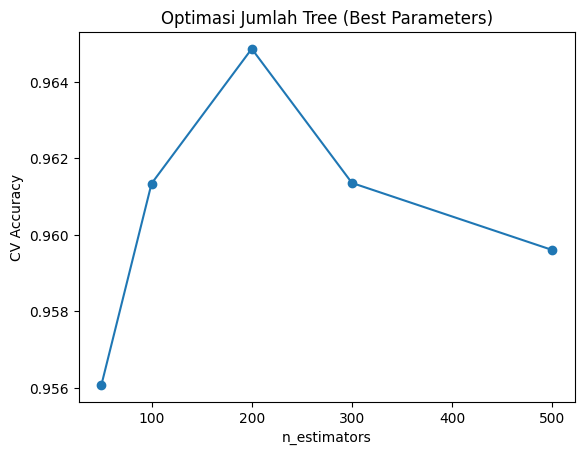

In [ ]:
# Ambil parameter terbaik dari hasil tuning
best_rf = df_sorted.iloc[0]

best_depth = int(best_rf['max_depth'])
best_feat = best_rf['max_features']
best_leaf = best_rf['min_samples_leaf']

print("Best Parameters:")
print(f"max_depth={best_depth}, max_features={best_feat}, min_samples_leaf={best_leaf}")

# Uji Jumlah Tree
n_estimators_list = [50, 100, 200, 300, 500]
rf_scores = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_depth,
        max_features=best_feat,
        min_samples_leaf=best_leaf,
        random_state=42
    )

    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores.append(score)

    print(f"n_estimators={n} -> Accuracy={score:.4f}")

# Visualisasi
import matplotlib.pyplot as plt

plt.plot(n_estimators_list, rf_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Optimasi Jumlah Tree (Best Parameters)")
plt.show()